<!-- @format -->

# Tiền xử lí dữ liệu - Gộp 2 dataset thành một

**Mục tiêu:** Gộp 2 nguồn dữ liệu (`dataKaggle` và `dataRoboflow`) thành 1 dataset thống nhất format YOLO cho việc train YOLOv8n.

| Dataset      | Format gốc     | Classes                         |
| ------------ | -------------- | ------------------------------- |
| dataKaggle   | Pascal VOC XML | `With Helmet`, `Without Helmet` |
| dataRoboflow | YOLO txt       | `helmets` (0), `no helmets` (1) |

**Class mapping thống nhất:**

- `0` → helmet (đội mũ)
- `1` → no helmet (không đội mũ)


In [1]:
import os
import xml.etree.ElementTree as ET
import shutil
import random
from pathlib import Path
from collections import Counter

# Đường dẫn gốc
BASE_DIR = Path(r"D:\Project_CV\Helmet_Detection\ai-model")
KAGGLE_DIR = BASE_DIR / "datasets" / "dataKaggle"
ROBOFLOW_DIR = BASE_DIR / "datasets" / "dataRoboflow"

# Đường dẫn output - dataset gộp
OUTPUT_DIR = BASE_DIR / "data4training"

print(f"Kaggle dir: {KAGGLE_DIR}")
print(f"Roboflow dir: {ROBOFLOW_DIR}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Kaggle exists: {KAGGLE_DIR.exists()}")
print(f"Roboflow exists: {ROBOFLOW_DIR.exists()}")

Kaggle dir: D:\Project_CV\Helmet_Detection\ai-model\datasets\dataKaggle
Roboflow dir: D:\Project_CV\Helmet_Detection\ai-model\datasets\dataRoboflow
Output dir: D:\Project_CV\Helmet_Detection\ai-model\data4training
Kaggle exists: True
Roboflow exists: True


<!-- @format -->

## 1. Khảo sát dữ liệu gốc


In [2]:
kaggle_images = sorted((KAGGLE_DIR / "images").glob("*.*"))
kaggle_xmls = sorted((KAGGLE_DIR / "annotations").glob("*.xml"))

In [3]:
# === Khảo sát dataKaggle ===
print("=" * 50)
print("DATASET KAGGLE")
print("=" * 50)
print(f"Số ảnh: {len(kaggle_images)}")
print(f"Số annotation XML: {len(kaggle_xmls)}")

DATASET KAGGLE
Số ảnh: 764
Số annotation XML: 764


In [4]:
# Thống kê class trong Kaggle
kaggle_class_count = Counter()
for xml_path in kaggle_xmls:
    tree = ET.parse(xml_path)

    # Duyệt qua các object trong XML để đếm class
    root = tree.getroot()
    for obj in root.findall("object"):
        # Lấy tên class từ thẻ <name> và đếm số lượng xuất hiện của từng class (With Helmet, Without Helmet)
        class_name = obj.find("name").text
        kaggle_class_count[class_name] += 1

print(f"Phân bố class:")
for cls, count in kaggle_class_count.most_common():
    print(f"  {cls}: {count}")

Phân bố class:
  With Helmet: 962
  Without Helmet: 489


In [5]:
# === Khảo sát dataRoboflow ===
print("\n" + "=" * 50)
print("DATASET ROBOFLOW")
print("=" * 50)
roboflow_stats = {}
for split in ["train", "valid", "test"]:
    imgs = list((ROBOFLOW_DIR / split / "images").glob("*.*"))
    lbls = list((ROBOFLOW_DIR / split / "labels").glob("*.txt"))
    roboflow_stats[split] = {"images": len(imgs), "labels": len(lbls)}
    print(f"{split}: {len(imgs)} ảnh, {len(lbls)} labels")


DATASET ROBOFLOW
train: 732 ảnh, 732 labels
valid: 93 ảnh, 93 labels
test: 183 ảnh, 183 labels


In [6]:
# Thống kê class trong Roboflow
roboflow_class_count = Counter()
for split in ["train", "valid", "test"]:
    for lbl_path in (ROBOFLOW_DIR / split / "labels").glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    roboflow_class_count[int(parts[0])] += 1

print(f"Phân bố class (0=helmets, 1=no helmets):")
for cls, count in sorted(roboflow_class_count.items()):
    print(f"  {cls}: {count}")



Phân bố class (0=helmets, 1=no helmets):
  0: 1168
  1: 498


In [7]:
total_images = len(kaggle_images) + sum(v["images"] for v in roboflow_stats.values())
print(f"\n>>> Tổng ảnh cả 2 dataset: {total_images}")


>>> Tổng ảnh cả 2 dataset: 1772


<!-- @format -->

## 2. Convert dataKaggle từ VOC XML sang YOLO format

**Class mapping:**

- `With Helmet` → `0` (helmet)
- `Without Helmet` → `1` (no helmet)

Đồng nhất với dataRoboflow: `helmets`=0, `no helmets`=1


<!-- @format -->

**Chuyển đổi định dạng label trong file xml sang định dạng label để dùng cho mô hinh YOLOv8n**

- Vì mô hình tự động resize lại ảnh để đúng với kích thước cạnh lớn nhất có độ dài là 640
- Chính vì vậy cần phải lấy label theo tỉ lệ cho đúng định dạng chứ không phải vị trí cụ thể


In [8]:
# Mapping class Kaggle -> YOLO class ID
KAGGLE_CLASS_MAP = {
    "With Helmet": 0,
    "Without Helmet": 1,
}

In [9]:
def convert_voc_to_yolo(xml_path):
    """Chuyển 1 file VOC XML sang danh sách dòng YOLO format."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Lấy kích thước ảnh
    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    yolo_lines = []
    for obj in root.findall("object"):
        class_name = obj.find("name").text
        if class_name not in KAGGLE_CLASS_MAP:
            print(f"  [WARNING] Class không xác định: '{class_name}' trong {xml_path.name}")
            continue

        class_id = KAGGLE_CLASS_MAP[class_name]
        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        # Clamp giá trị vào khoảng hợp lệ
        xmin = max(0, min(xmin, img_w))
        ymin = max(0, min(ymin, img_h))
        xmax = max(0, min(xmax, img_w))
        ymax = max(0, min(ymax, img_h))

        # Chuyển sang YOLO normalized format
        x_center = (xmin + xmax) / 2.0 / img_w
        y_center = (ymin + ymax) / 2.0 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        # Bỏ qua bbox quá nhỏ hoặc không hợp lệ
        if width <= 0 or height <= 0:
            continue

        yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    return yolo_lines

# Test với 1 file
test_lines = convert_voc_to_yolo(kaggle_xmls[0])
print(f"File: {kaggle_xmls[0].name}")
print(f"Số object: {len(test_lines)}")
for line in test_lines:
    print(f"  {line}")

File: BikesHelmets0.xml
Số object: 4
  0 0.138750 0.496255 0.132500 0.205993
  0 0.393750 0.411985 0.177500 0.329588
  0 0.558750 0.264045 0.112500 0.205993
  0 0.847500 0.232210 0.160000 0.337079


<!-- @format -->

## 3. Gộp 2 dataset và chia train/val/test

- Gộp tất cả ảnh + label vào chung 1 pool
- Chia theo tỷ lệ: **80% train / 10% val / 10% test**
- Đảm bảo không trùng lặp file name bằng cách thêm prefix nguồn


In [10]:
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

In [11]:
# Tạo thư mục output
for split in ["train", "val", "test"]:
    (OUTPUT_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

In [12]:
all_samples = []

# --- Xử lý dataKaggle: convert VOC XML -> YOLO ---
print("Xử lý dataKaggle...")
skipped_kaggle = 0
for xml_path in kaggle_xmls:
    # Tìm ảnh tương ứng
    img_path = None
    for ext in [".png", ".jpg", ".jpeg"]:
        candidate = KAGGLE_DIR / "images" / (xml_path.stem + ext)
        if candidate.exists():
            img_path = candidate
            break

    if img_path is None:
        skipped_kaggle += 1
        continue

    # Convert label
    yolo_lines = convert_voc_to_yolo(xml_path)
    if not yolo_lines:
        skipped_kaggle += 1
        continue

    # Thêm prefix "kg_" để tránh trùng tên
    new_stem = f"kg_{xml_path.stem}"
    all_samples.append({
        "img_path": img_path,
        "label_lines": yolo_lines,
        "stem": new_stem,
        "img_ext": img_path.suffix,
        "source": "kaggle",
    })

print(f"  Kaggle: {len([s for s in all_samples if s['source'] == 'kaggle'])} samples (bỏ qua {skipped_kaggle})")


Xử lý dataKaggle...
  Kaggle: 756 samples (bỏ qua 8)


In [13]:

# --- Xử lý dataRoboflow: đã sẵn YOLO format ---
print("Xử lý dataRoboflow...")
roboflow_count = 0
for split in ["train", "valid", "test"]:
    img_dir = ROBOFLOW_DIR / split / "images"
    lbl_dir = ROBOFLOW_DIR / split / "labels"

    for img_path in img_dir.glob("*.*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue

        # Đọc label
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]

        if not lines:
            continue

        # Thêm prefix "rb_" để tránh trùng tên
        new_stem = f"rb_{img_path.stem}"
        all_samples.append({
            "img_path": img_path,
            "label_lines": lines,
            "stem": new_stem,
            "img_ext": img_path.suffix,
            "source": "roboflow",
        })
        roboflow_count += 1

print(f"  Roboflow: {roboflow_count} samples")
print(f"\n>>> TỔNG: {len(all_samples)} samples")

Xử lý dataRoboflow...
  Roboflow: 972 samples

>>> TỔNG: 1728 samples


In [14]:
# ============================================================
# BƯỚC 2: Shuffle và chia train/val/test
# ============================================================
random.seed(42)
random.shuffle(all_samples)

n = len(all_samples)
n_train = int(n * TRAIN_RATIO)
n_val = int(n * VAL_RATIO)

train_samples = all_samples[:n_train]
val_samples = all_samples[n_train:n_train + n_val]
test_samples = all_samples[n_train + n_val:]

print(f"Phân chia dataset:")
print(f"  Train: {len(train_samples)}")
print(f"  Val:   {len(val_samples)}")
print(f"  Test:  {len(test_samples)}")

Phân chia dataset:
  Train: 1382
  Val:   172
  Test:  174


In [15]:


# ============================================================
# BƯỚC 3: Copy ảnh + ghi label vào thư mục output
# ============================================================
for split_name, samples in [("train", train_samples), ("val", val_samples), ("test", test_samples)]:
    for sample in samples:
        # Copy ảnh
        dst_img = OUTPUT_DIR / "images" / split_name / (sample["stem"] + sample["img_ext"])
        shutil.copy2(sample["img_path"], dst_img)

        # Ghi label
        dst_lbl = OUTPUT_DIR / "labels" / split_name / (sample["stem"] + ".txt")
        with open(dst_lbl, "w") as f:
            f.write("\n".join(sample["label_lines"]))

print(f"\nĐã ghi dataset vào: {OUTPUT_DIR}")

# Kiểm tra kết quả
for split in ["train", "val", "test"]:
    n_img = len(list((OUTPUT_DIR / "images" / split).glob("*.*")))
    n_lbl = len(list((OUTPUT_DIR / "labels" / split).glob("*.txt")))
    print(f"  {split}: {n_img} ảnh, {n_lbl} labels")


Đã ghi dataset vào: D:\Project_CV\Helmet_Detection\ai-model\data4training
  train: 1382 ảnh, 1382 labels
  val: 172 ảnh, 172 labels
  test: 174 ảnh, 174 labels


<!-- @format -->

## 4. Tạo file data.yaml cho YOLOv8


In [16]:
import yaml

data_yaml = {
    "path": OUTPUT_DIR.as_posix(),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 2,
    "names": {
        0: "helmet",
        1: "no helmet",
    },
}

yaml_path = OUTPUT_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print(f"Đã tạo: {yaml_path}")
print()
with open(yaml_path) as f:
    print(f.read())

Đã tạo: D:\Project_CV\Helmet_Detection\ai-model\data4training\data.yaml

path: D:/Project_CV/Helmet_Detection/ai-model/data4training
train: images/train
val: images/val
test: images/test
nc: 2
names:
  0: helmet
  1: no helmet



<!-- @format -->

## 5. Kiểm tra chất lượng dữ liệu

Thống kê phân bố class trong dataset cuối cùng và hiển thị một vài sample để xác nhận label đúng.


Phân bố class trong dataset cuối cùng:
Split        helmet    no helmet     Tổng
------------------------------------------
train          1715          787     2502
val             186          100      286
test            219           93      312
------------------------------------------
TOTAL          2120          980     3100


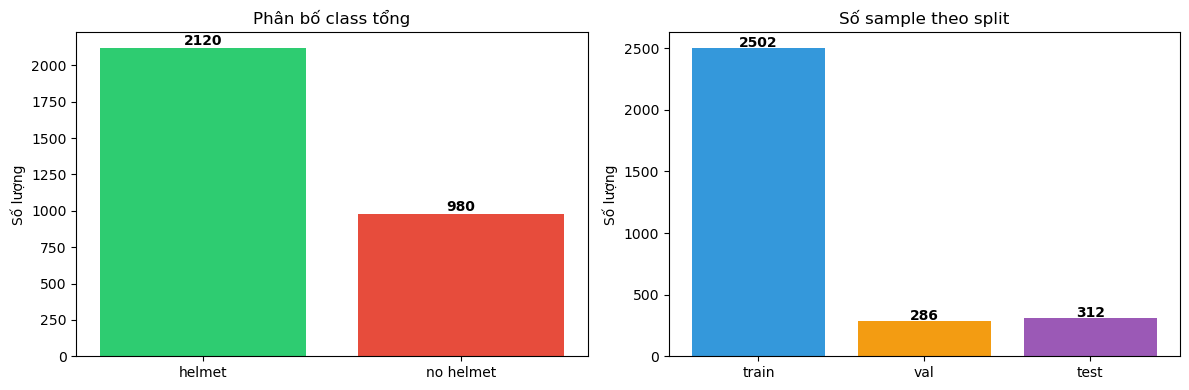

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# --- Thống kê phân bố class cuối cùng ---
final_class_count = Counter()
final_split_class = {}

for split in ["train", "val", "test"]:
    split_count = Counter()
    for lbl_path in (OUTPUT_DIR / "labels" / split).glob("*.txt"):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls_id = int(parts[0])
                    split_count[cls_id] += 1
                    final_class_count[cls_id] += 1
    final_split_class[split] = split_count

CLASS_NAMES = {0: "helmet", 1: "no helmet"}

print("Phân bố class trong dataset cuối cùng:")
print(f"{'Split':<8} {'helmet':>10} {'no helmet':>12} {'Tổng':>8}")
print("-" * 42)
for split in ["train", "val", "test"]:
    c = final_split_class[split]
    total = sum(c.values())
    print(f"{split:<8} {c.get(0,0):>10} {c.get(1,0):>12} {total:>8}")
print("-" * 42)
print(f"{'TOTAL':<8} {final_class_count.get(0,0):>10} {final_class_count.get(1,0):>12} {sum(final_class_count.values()):>8}")

# --- Biểu đồ phân bố ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ 1: class distribution
classes = list(CLASS_NAMES.values())
counts = [final_class_count.get(i, 0) for i in range(2)]
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(classes, counts, color=colors)
axes[0].set_title("Phân bố class tổng")
axes[0].set_ylabel("Số lượng")
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# Biểu đồ 2: split distribution
split_names = ["train", "val", "test"]
split_totals = [sum(final_split_class[s].values()) for s in split_names]
axes[1].bar(split_names, split_totals, color=["#3498db", "#f39c12", "#9b59b6"])
axes[1].set_title("Số sample theo split")
axes[1].set_ylabel("Số lượng")
for i, v in enumerate(split_totals):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

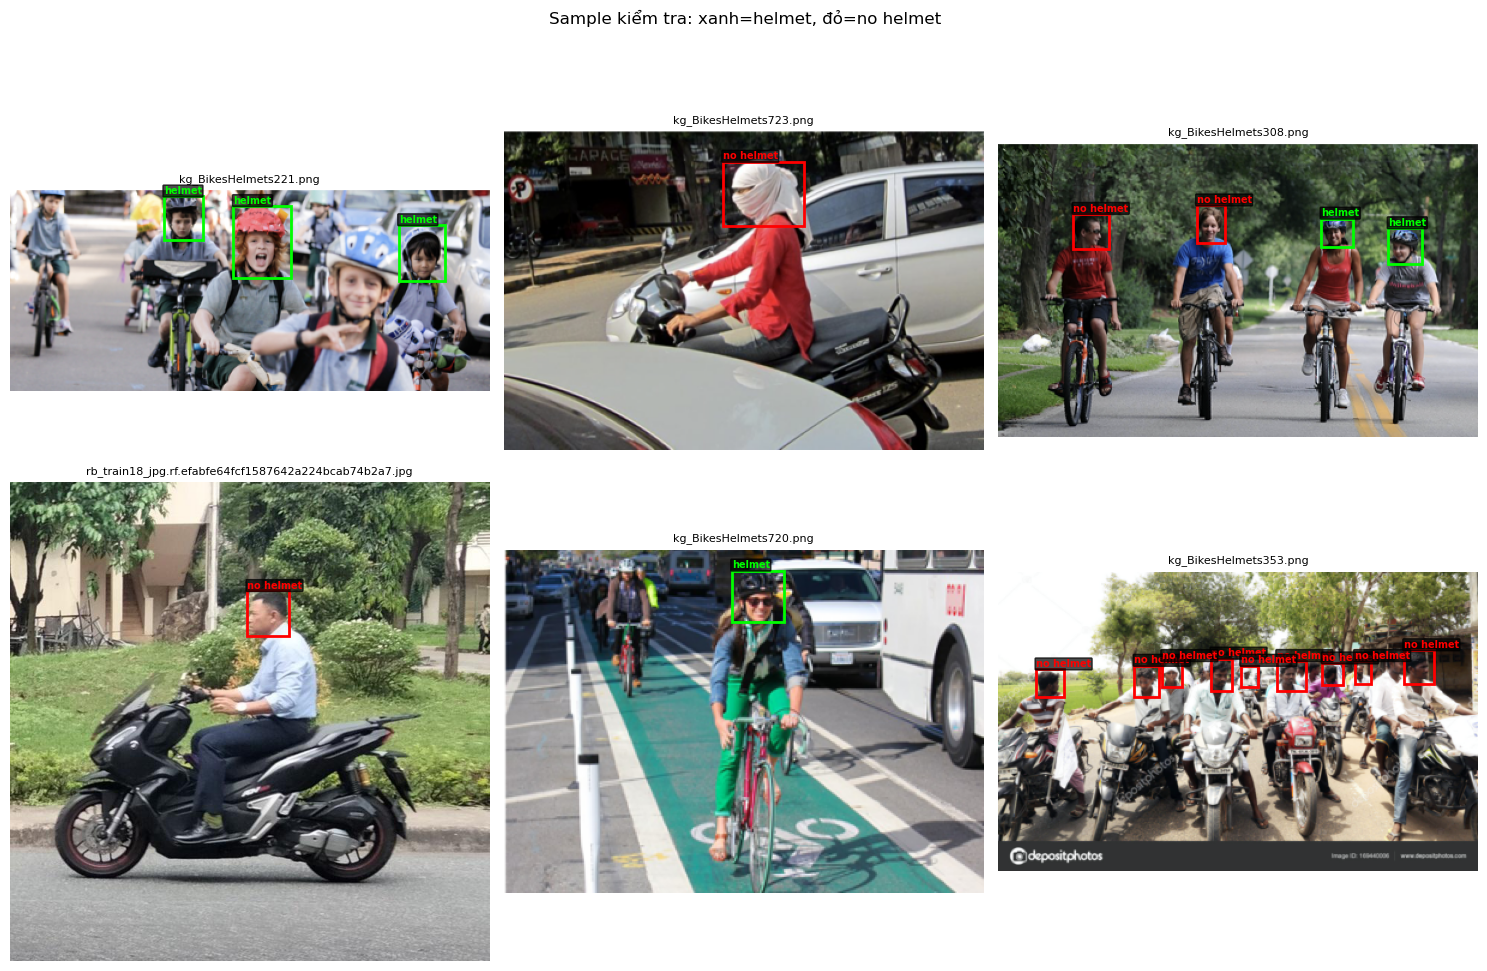


✅ Preprocessing hoàn tất! Dataset sẵn sàng để train.
Đường dẫn data.yaml: D:\Project_CV\Helmet_Detection\ai-model\data4training\data.yaml


In [18]:
# --- Visualize vài sample để kiểm tra label ---
COLORS = {0: "lime", 1: "red"}

def visualize_sample(img_path, lbl_path, ax):
    """Hiển thị ảnh với bounding box từ YOLO label."""
    img = Image.open(img_path)
    w, h = img.size
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])

                # Convert YOLO -> pixel
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                box_w = bw * w
                box_h = bh * h

                color = COLORS.get(cls_id, "yellow")
                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2, edgecolor=color, facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 2, CLASS_NAMES.get(cls_id, "?"),
                       color=color, fontsize=7, fontweight="bold",
                       bbox=dict(boxstyle="round,pad=0.1", facecolor="black", alpha=0.7))

# Lấy 6 sample ngẫu nhiên từ train
train_images = sorted((OUTPUT_DIR / "images" / "train").glob("*.*"))
random.seed(123)
sample_imgs = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flat, sample_imgs):
    lbl_path = OUTPUT_DIR / "labels" / "train" / (img_path.stem + ".txt")
    visualize_sample(img_path, lbl_path, ax)

plt.suptitle("Sample kiểm tra: xanh=helmet, đỏ=no helmet", fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Preprocessing hoàn tất! Dataset sẵn sàng để train.")
print(f"Đường dẫn data.yaml: {OUTPUT_DIR / 'data.yaml'}")